# Detection and Classification Results

In [1]:
from utils.calculate_metrics import calculate_metrics
from sklearn.metrics import classification_report

print("Clf:")

for model in ['HyperGT-tablet', 'STGCN-tablet', 'CTRGCN-tablet', 'HDGCN-tablet','MyModel-tablet']:
    result, _, _ = calculate_metrics(f"./ckpts/{model}/clf/clf_test_results.csv")
    print(f"{model} & {result} \\\\ \\hline")

print("Detection:")

for model in ['HyperGT-tablet', 'STGCN-tablet', 'CTRGCN-tablet', 'HDGCN-tablet', 'MyModel-tablet']:
    result, _, _ = calculate_metrics(f"./ckpts/{model}/det/det_test_results.csv")
    print(f"{model} & {result} \\\\ \\hline")

Clf:
HyperGT-tablet & 0.9317 & 0.9017 & 0.8634 & 0.8606 \\ \hline
STGCN-tablet & 0.9239 & 0.8916 & 0.8554 & 0.8441 \\ \hline
CTRGCN-tablet & 0.9209 & 0.8732 & 0.8423 & 0.8422 \\ \hline
HDGCN-tablet & 0.9284 & 0.9055 & 0.8780 & 0.8720 \\ \hline
MyModel-tablet & 0.9345 & 0.9234 & 0.8877 & 0.8684 \\ \hline
Detection:
HyperGT-tablet & 0.9581 & 0.8540 & 0.8753 & 0.9004 \\ \hline
STGCN-tablet & 0.9556 & 0.8501 & 0.8656 & 0.8831 \\ \hline
CTRGCN-tablet & 0.9467 & 0.8340 & 0.8285 & 0.8233 \\ \hline
HDGCN-tablet & 0.9536 & 0.8543 & 0.8523 & 0.8502 \\ \hline
MyModel-tablet & 0.9561 & 0.8661 & 0.8579 & 0.8501 \\ \hline


# Confusion matrix with keystrokes grouped 

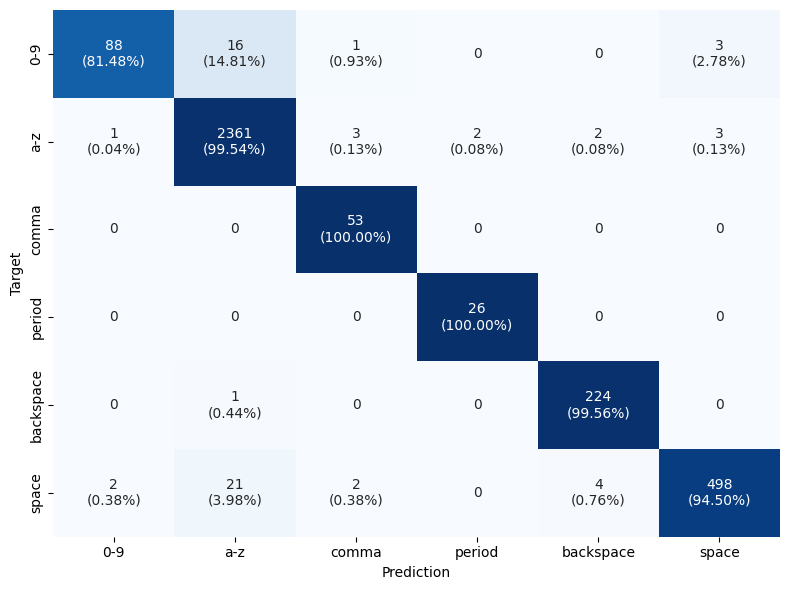

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define category mapping function
def categorize(char):
    if char.isdigit():
        return "0-9"
    elif char.isalpha() and len(char) == 1:
        return "a-z"
    else:
        return char

# Load CSV
df = pd.read_csv("/GitHub/keystroke-v2/ckpts/MyModel-tablet/clf/clf_test_results.csv")

# Map predictions and targets to categories
df["pred_category"] = df["pred"].astype(str).apply(categorize)
df["target_category"] = df["target"].astype(str).apply(categorize)

# Define categories
categories = ["0-9", "a-z", "comma", "period", "backspace", "space"]

# Compute confusion matrix
cm = confusion_matrix(df["target_category"], df["pred_category"], labels=categories)

# Normalize by row (true labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized)  # Replace NaNs from division by zero

# Create combined annotation: raw count + newline + percentage
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count = cm[i, j]
        pct = cm_normalized[i, j] * 100
        if count == 0:
            annot[i, j] = "0"
        else:
            annot[i, j] = f"{count}\n({pct:.2f}%)"

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=annot, fmt='', xticklabels=categories, yticklabels=categories, cmap="Blues", cbar=False)
plt.xlabel("Prediction")
plt.ylabel("Target")
plt.tight_layout()
plt.savefig('confusion.png', dpi=300)
plt.show()


# Stream results

In [6]:
import pandas as pd
from utils.realtime_util import process_prediction, evaluate, remove_consecutive_letters
avg_eds = 0
avg_wer = 0


def convert_to_gt(csv):
    df = pd.read_csv(csv)
    result = ""
    # Loop through each key and apply the rules
    for index, row in df.iterrows():
        key = row['Key']
        
        if key == 'space':
            result += ' '
        elif key == 'period':
            result += '.'
        elif key == 'comma':
            result += ','
        elif key == 'backspace' and len(result) > 0:
            result = result[:-1]  # Remove the last character
        else:
            result += key  # Add the key character to the result

    return result

corrected = {
    16: "In the heart of a mystical valley, explorers uncovered a hidden realm where the alphabet from A to Z adorned ancient stones, each carving vibrant meanings. A quick brown fox sprinted past glittering waterfalls, while frogs perched on lily pads in a pond, shimmering merrily at the edges. Overhead, luminous birds soared, their wings reflecting the flight of golden orbs. Among the lush greenery, blooming orchids reached toward the sky, and fireflies danced in perfect, quiet unison. As the canopy of twinkling stars above glistened, the adventurers marveled at the harmony of letters, numbers, and the magic of the universe.",
    
    17: "The five boxing wizards jumped quickly. Pack my box with five dozen liquor jugs, they said. The lazy, fat oxen plodded slowly, while frogs hopped and jumped swiftly. When zombies arrived, the judge quickly faxed his decision. Amazingly, a few discovered that jukeboxes provided the best music. Puzzled, some men bequeathed their erks as very enthusiastic gifts. The quick goblin jumped over the lazy dog. Brawny ghouls just flocked to quiz and vex him. Watching, they paraded through the beaks of birds, and six big devils from Japan quickly forgot how to waltz. Five or six big jet planes zoomed quickly by the tower. Jack amazed a few girls by dropping the antique on a vase. A quick movement of the enemy will parade six gunboats. Zombies zigzagged quietly but kept driving their losses forward. No kidding, a Florida man called off his trip to Mexico City because they told him the conquistadors were extinct.",
    
    18: "Dear Quincy, I hope you are doing well. I wanted to update you on our latest project, which has been quite the journey. The work involves a series of complex tasks, each with its unique challenges. Our team, including Kevin and Zael Ada, has been diligently working to tackle these issues. Recently, we faced several key situations that required immediate attention. Thankfully, we managed to address them with the help of our innovative techniques and quick adjustments. The process has been quite rigorous, but we are making significant strides. Our project is driven by advanced algorithms and cutting-edge technology. We look forward to sharing more updates with you soon. Best regards,   Jack Q. Ozimer",
    
    19: "The energetic fox dashed across winding paths, leaping over lazy dogs and playfully chasing squirrels as it zigzagged, while birds flew overhead, their wings casting quick shadows. In the meadow, rabbits hopped across patches of daisies, nibbling on blades of grass, while butterflies fluttered nearby. The sun, slowly lowering on the horizon, bathed the land in a soft amber glow as frogs croaked from the nearby pond. At the edge of the field, crickets began their chorus, their rhythmic sounds blending with the breeze, while fireflies lit up the dusky air.",
    
    
    20: "Dear Bincy, I hope you are doing well. I wanted to update you on our latest project, which has been quite the journey. The work involves a series of complex tasks, each with its unique challenges. Our team, including Kevin and Nezaled, has been diligently working to tackle these issues. Recently, we faced several quick-key situations that required immediate attention. Thankfully, we managed to address them with the help of our innovative techniques and quick adjustments. The process has been quite rigorous, but we are making significant strides. Our project is driven by advanced algorithms and cutting-edge technology. We look forward to sharing more updates with you soon. Best regards, Jack Q. Zimmer",
    
    21: "Amid the vibrant festival in June, lively musicians played tunes from A to Z. The crowd cheered as glowing lanterns lit up the sky, while balloons floated above the scene. The quick fox jumped over lazy dogs' tails, barking loudly each time. An owl hooted as frogs hopped along the path, observing the scattered petals of Arabian blossoms coloring the bouquet. By midnight, twinkling stars illuminated the air, and partygoers sang in harmony, clapping and shouting numbers like, 1, 2, 3, and with jubilant joy, celebrating life to the fullest.",
    
    22: "In the bustling town square, jugglers performed tricks with glowing balls marked A to Z, dazzling a large crowd of cheering onlookers. A quick brown fox darted between colorful stalls, while frogs croaked melodiously by the degree fountain. Nearby, musicians played a lively tune, their instruments creating a symphony of sound. As the clock struck, fireworks lit up the sky, and children clapped in delight. The energy of the night was electric, with stars twinkling above and laughter echoing from all corners, celebrating the unbreakable rhythm of life, letters, and numbers.",
    
    23: "On a breezy summer afternoon, adventurers wandered through vibrant meadows, their voices carried by a quick brown fox dashing past grazing deer, while frogs croaked near a glimmering stream. Overhead, birds circled the sky, and dragonflies danced above ripples in the water. Nearby, flowers bloomed in radiant colors, attracting buzzing bees. As dusk fell, the stars lit up the heavens, showcasing the beauty of nature's endless patterns and the harmony between the alphabet and numbers in their journey.",
    
    24: "Curious children wandered into the enchanted forest, guided by stars marked with letters A through Z. The quick brown fox playfully darted between towering trees, while frogs leapt into a deep, crystal-clear pond. Overhead, sparrows flew, their songs echoing in the light. The adventurers noticed mushrooms growing in spirals, and spotted fireflies blinking in rhythmic harmony. As night fell, under a sky almost glowing with stars, they shared stories, blending the magic of letters and numbers into an unforgettable tale.",
    
}
    

for i in [16, 18, 20, 22]:
    print(f"----Video {i}----")
    pred = process_prediction(f'./stream_results/{i}.csv', active_thres=0.70, key_thres=0.9)
    print("".join(pred))
    pred = remove_consecutive_letters(pred)
    print("".join(pred))
    result = convert_to_gt(f"./datasets/KeyVR-v2/labels/video_{i}.csv")
    e, w = evaluate(corrected[i], result)

----Video 16----
iinnnnnn      tttthhheeeee      hhhheeaaaaaarrr   tttttt     oooooooooooffffff        aa     mmmyyyyyyssssstttttiiiccccahaaalllll      vvvvvvvaaaaaallllllllaaayyyyys,,,,,     u    sseeeeopppplllloooorrrrreeeeeerrr  wsa       uuuunnnnocccooooovvvveeeerrrreeeeeeeeeddddd        aaaaa     hhhhiiiddddddddeeeennnnn       rrrreeeeeeaaaaallllaaaammmm       wwwwhhheeeeeerrrrreeeee       sssaatttthhhheeeee        aaaalllllphhhaaaaaaabbbbbeeeeetttttt    fffrrrrr ooooommmm        aaaa    ttt  oooooo       aa zzzaa     aaaaaaawwdddooooorrrnnnneeeeeddddd     nnnnnnnccccciiiieeeeennnntttttt    ss  ssaattttt  oooonnneeeee      ccccaaarrrr  vvvvviiionnnnnngggggsssss..........      a    aaa      qqquuuuuuiiiiiccccckkk       bbbbrrrroooowwwnnnn     ffffoooooxxxss     ssssppppparrrriiiiinnnnddddd      ppppppaasssstttt           gggg llllliiiittttttttttteeeerrriiiinnnnnnggggg    wwwwaaaaaattttteeeeeeerrfffffoaaallllllsssss      ,,e     wwwwhhhiiiillllleeeee           ffffrrr   ggoaoooooggg